# Ecosmic Use Case - DISCOSWeb ETL pipeline

In [ ]:
from datetime import datetime
from dotenv import load_dotenv
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import plotly.express as px
from pprint import pprint
import requests
import seaborn as sns

## Data Extraction & Filtering

In [ ]:
# Defining the URL and token for the API request

load_dotenv(dotenv_path='token.env')

URL =  'https://discosweb.esoc.esa.int/api/objects'
token = os.environ.get('DISCOS_API_TOKEN')
if not token:
    raise ValueError("DISCOS_API_TOKEN not found in environment variables. Please set it.")

In [99]:

# CHECKING RATE LIMITS
# The rate limit is 100 requests per minute

response = requests.get(
    f'{URL}',
    headers={
        'Authorization': f'Bearer {token}',
        'DiscosWeb-Api-Version': '2',
    },
    params={
        'filter': "gt(reentry.epoch,epoch:'2025-01-01')&ne(mass,0.0)",
    },
)

doc1 = response.json()
if response.ok:
    pass
else:
    errors = doc1.get('errors', 'No errors key found in response')
    pprint(errors)


rate_limit =  response.headers.get('X-RateLimit-Limit')
rate_window = response.headers.get('X-RateLimit-Window')
reset_time = response.headers.get('X-RateLimit-Reset')

print('Rate limit:', rate_limit)
print('Rate window:', rate_window)
datetime.fromtimestamp(int(reset_time)).isoformat() 


Rate limit: 100
Rate window: None


'2025-04-08T15:53:45'

In [3]:
raw_data = [] # List to store dowloaded data of all pages
MAX_RETRIES = 3 # Maximum number of retries in case of server errors

# The following loop is designed to fetch data from all the pages of the API
# store it in the raw_data list and save it in a JSON file
while URL:

    print(f'Fetching {URL}')
    print(f'Current URL: {URL}') # Check if the current URL is the one we expect to be fetching

    for attempt in range(1, MAX_RETRIES + 1):
        
        # Making the request to the API
        response = requests.get(
            f'{URL}',
            headers={
                'Authorization' : f'Bearer {token}',
                'DiscosWeb-Api-Version' : '2',
            },
            params={
                'filter': "gt(reentry.epoch,epoch:'2025-01-01')&ne(mass,0.0)",
            },
        )

        # Print status code of the response
        print(f'Status code: {response.status_code}')

        # If we get a server error (502 or 503), we will retry the request after 3 secs
        # and up to MAX_RETRIES times
        if response.status_code in [502,503]:
            print(f'Server error {response.status_code}. Retry {attempt}/{MAX_RETRIES}...')
            time.sleep(3)
            continue

        break
    
    # Error message in case of failure of server connection after MAX_RETRIES
    if response.status_code in [502,503]:
        print(f'Failed to fetch data after {MAX_RETRIES} attempts.')
        break

    # Handling errors in case of failure to decode JSON response
    # or if the response is not a valid JSON
    try:
        doc = response.json() # Decode the JSON response

    # Using the built-in exception class to catch runtime errors in decoding JSON 
    # and print the first 300 charcaters of the error message 
    except Exception as e:
        print('Failed to decode JSON response')
        print('Response content:', response.content[:300])
        break
    
    # Check if the response is valid:
    # If the response is VALID, we filter the data and store it in raw_data;
    # If the response is NOT VALID, we print the error message
    # and break the loop.
    if response.ok:
        
        # Filter out relationships and links from the objects (data)
        filtered_data = [
            {k: v for k, v in obj.items() if k in ['type', 'id', 'attributes']}
            for obj in doc.get('data', [])
        ]
        raw_data.extend(filtered_data) # Append filtered data to the raw_data list

        # Save data to a JSON file every 100 records
        if len(raw_data) % 100 == 0:
            with open('raw_data_filtered.json', 'w') as f:
                json.dump(raw_data, f, indent=2)

        # Get the next page URL from the response and update the URL variable
        # to fetch the next page of data
        # If there is no next page, set URL to None to stop the loop.
        next_page = doc.get('links', {}).get('next')
        if next_page:
            next_page = next_page.replace('/api/objects','') # Remove the URL path already included in the URL
            next_URL = 'https://discosweb.esoc.esa.int/api/objects'+ next_page # Define next URL
            if next_URL == URL:
                print('Next URL is the same as current URL, stopping to avoid infinite loop.')
                break
            URL = next_URL # Update URL to the next page
        else:
            URL = None

        print(f'Next page: {next_page}')
    
    else:
        # Print error message if the response is not valid
        pprint(doc['errors'])
        break

Fetching https://discosweb.esoc.esa.int/api/objects
Current URL: https://discosweb.esoc.esa.int/api/objects
Status code: 200
Next page: ?filter=gt(reentry.epoch,epoch:'2025-01-01')%26ne(mass,0.0)&page%5Bnumber%5D=2
Fetching https://discosweb.esoc.esa.int/api/objects?filter=gt(reentry.epoch,epoch:'2025-01-01')%26ne(mass,0.0)&page%5Bnumber%5D=2
Current URL: https://discosweb.esoc.esa.int/api/objects?filter=gt(reentry.epoch,epoch:'2025-01-01')%26ne(mass,0.0)&page%5Bnumber%5D=2
Status code: 200
Next page: ?filter=gt(reentry.epoch,epoch:'2025-01-01')%26ne(mass,0.0)&page%5Bnumber%5D=3&filter=gt(reentry.epoch,epoch:'2025-01-01')%26ne(mass,0.0)
Fetching https://discosweb.esoc.esa.int/api/objects?filter=gt(reentry.epoch,epoch:'2025-01-01')%26ne(mass,0.0)&page%5Bnumber%5D=3&filter=gt(reentry.epoch,epoch:'2025-01-01')%26ne(mass,0.0)
Current URL: https://discosweb.esoc.esa.int/api/objects?filter=gt(reentry.epoch,epoch:'2025-01-01')%26ne(mass,0.0)&page%5Bnumber%5D=3&filter=gt(reentry.epoch,epoch:'2

Practices for future implementations:
- Consider other types of errors to allow for a more comprehensive error handling practice
- Track rate limiting properly: insert in the loop cycle a counter in order to have maximum 100 requests per minute
- I went all-in with security assumptions :) - to be completely structured: how to ensure security of the connection?

## Data Transformation & Analysis

### Transforming data into a suitable format for analysis

In [116]:
# Loading data from the json file and normalizing it into a pandas DataFrame

data = json.load(open('raw_data_filtered.json'))
df = pd.json_normalize(data, sep='_')

In [ ]:
# Summary statistics and info about the dataframe

df.head() # Visualize head of df
df.info() # Check general info about values of the df
df.isnull().sum() # Count missing values
df.dtypes # Visualize data types of columns
df.describe() # Summary statistcs of df
df[df.duplicated()] # Check for duplicates

In [101]:
# Check entries of the dataframe that have missing values
df[df[['attributes_width','attributes_depth']].isnull().any(axis=1)] #,'attributes_span'

,type,id,attributes_cosparId,attributes_vimpelId,attributes_satno,attributes_name,attributes_objectClass,attributes_mass,attributes_shape,attributes_width,...,attributes_span,attributes_xSectMax,attributes_xSectMin,attributes_xSectAvg,attributes_firstEpoch,attributes_mission,attributes_predDecayDate,attributes_active,attributes_cataloguedFragments,attributes_onOrbitCataloguedFragments
2,object,40357,2014-087A,None,40360,Resurs-P No. 2,Payload,6392.0,Cyl + 2 Pan,NaN,...,13.0,44.333362,5.725553,27.080052,2014-12-26,Civil Imaging,None,False,0,0
48,object,64316,2020-060A,None,46268,Electron Photon-LEO,Payload,50.0,Trunc Cone,NaN,...,NaN,1.130973,0.300000,0.709308,2020-08-31,Commercial Technology,None,False,0,0
264,object,77200,2023-045A,None,56091,Cosmos-2568,Payload,520.0,Cyl + 2 Pan,NaN,...,3.0,4.119683,1.327323,3.726714,2023-03-29,Defense Imaging,None,False,0,0
294,object,85628,2024-145A,None,60450,Progress MS-28,Payload,7428.0,Cyl + Sphere + Cone + 2 Pan,NaN,...,7.9,22.085082,5.725553,19.615319,2024-08-15,Civil Spaceship,None,False,0,0
295,object,86427,2024-166A,None,61179,Cosmos-2577,Payload,520.0,Cyl + 2 Pan,NaN,...,3.0,4.119683,1.327323,3.726714,2024-09-17,Defense Imaging,None,False,0,0
297,object,88304,2024-236A,None,62263,Simorgh stage 2,Rocket Body,1490.0,Cyl,NaN,...,8.2,12.426295,1.767146,10.543970,2024-12-06,None,None,False,0,0


In [104]:
df[df['attributes_diameter'].notnull()]

,type,id,attributes_cosparId,attributes_vimpelId,attributes_satno,attributes_name,attributes_objectClass,attributes_mass,attributes_shape,attributes_width,...,attributes_span,attributes_xSectMax,attributes_xSectMin,attributes_xSectAvg,attributes_firstEpoch,attributes_mission,attributes_predDecayDate,attributes_active,attributes_cataloguedFragments,attributes_onOrbitCataloguedFragments
2,object,40357,2014-087A,None,40360,Resurs-P No. 2,Payload,6392.0,Cyl + 2 Pan,NaN,...,13.0,44.333362,5.725553,27.080052,2014-12-26,Civil Imaging,None,False,0,0
48,object,64316,2020-060A,None,46268,Electron Photon-LEO,Payload,50.0,Trunc Cone,NaN,...,NaN,1.130973,0.300000,0.709308,2020-08-31,Commercial Technology,None,False,0,0
264,object,77200,2023-045A,None,56091,Cosmos-2568,Payload,520.0,Cyl + 2 Pan,NaN,...,3.0,4.119683,1.327323,3.726714,2023-03-29,Defense Imaging,None,False,0,0
294,object,85628,2024-145A,None,60450,Progress MS-28,Payload,7428.0,Cyl + Sphere + Cone + 2 Pan,NaN,...,7.9,22.085082,5.725553,19.615319,2024-08-15,Civil Spaceship,None,False,0,0
295,object,86427,2024-166A,None,61179,Cosmos-2577,Payload,520.0,Cyl + 2 Pan,NaN,...,3.0,4.119683,1.327323,3.726714,2024-09-17,Defense Imaging,None,False,0,0
297,object,88304,2024-236A,None,62263,Simorgh stage 2,Rocket Body,1490.0,Cyl,NaN,...,8.2,12.426295,1.767146,10.543970,2024-12-06,None,None,False,0,0


The objects with missing values for both width and depth attributes are the same and they are the only objects having diameter values: they can be considered spheric.

Dealing with missing values:
- 'attributes_mission' entries are str type --> substitute
- 'attributes_width/depth/span' entries are numeric --> set to 0

In [ ]:
# Cleaning the dataframe

# Renaming columns
df.columns = (
    df.columns
    .str.replace('attributes_', '')
    .str.strip()
    .str.lower()
)

# Filling missing values
df['mission'].fillna('Unknown mission', inplace=True)
df['width'].fillna(0, inplace=True)
df['depth'].fillna(0, inplace=True)
df['diameter'].fillna(0, inplace=True)
df['span'].fillna(0, inplace=True)

In [118]:
# Save cleaned df to a csv file
df.to_csv('data.csv', index=False)

Future implementations:
- Use pandas-profiling/ydata-profiling

### Data Analysis and Visualization
The aim of the following analysis is to classify and study the shape of the objects with a focus on a specific dimension.

In [16]:
# Load csv file previously created
df = pd.read_csv('data.csv')
#df.head()

In [4]:
df['shape'].unique()
df['shape'].value_counts()

shape
Box + 1 Pan                    234
Box + 2 Pan                     36
Box                             24
Cyl + 2 Pan                      3
Trunc Cone                       1
Cyl + Sphere + Cone + 2 Pan      1
Cyl                              1
Name: count, dtype: int64

In [17]:
# Create new "simplified shape" column that records entries with spherical shape
spheric_shape = df[df['diameter']!=0]['shape'].unique().tolist()
df['simpshape'] = df['shape'].apply(
    lambda x: 'Spherical' if x in spheric_shape else x
)
df['simpshape'].unique()

array(['Box + 2 Pan', 'Box', 'Spherical', 'Box + 1 Pan'], dtype=object)

In [18]:
# Create column based on the volume of each object
df['volume'] = df.apply(
    lambda x: 4/3 * np.pi * (x['diameter']/2)**3
    if x['simpshape'] == 'Spherical' else
    (x['width'] * x['depth'] * x['span']),
    axis=1
)

In [63]:
df.groupby('simpshape')[['mass','volume','span']].agg(['mean','std','min','max']).reset_index()

simpshape         mass                                volume              \
                       mean          std   min     max       mean         std   
0          Box    13.019667    17.950030   0.3    67.0   0.127447    0.358994   
1  Box + 1 Pan   260.042735    18.231884  85.0   305.0  49.585295    6.105451   
2  Box + 2 Pan   301.408333   441.470283   0.5  2000.0  90.237596  145.204237   
3    Spherical  2733.333333  3285.409604  50.0  7428.0   4.264101    4.688704   

                             span                         
        min         max      mean        std   min   max  
0  0.000000    1.500000  0.341417   0.350505  0.00   1.5  
1  1.170000   70.560000  8.817436   0.518733  3.25   9.0  
2  0.000000  321.030000  8.841111  12.765710  0.00  29.0  
3  0.904779   10.305995  5.850000   4.718368  0.00  13.0

In [ ]:

fig = px.scatter_3d(df, x='volume', y='mass', z='span',
                    color='simpshape',  # Your shape-based class
                    #symbol='simpshape',  # Optional: shape based on shape
                    size='mass',         # Optional: scale by mass
                    hover_name='name'  # Add tooltips
                   )
#fig.select_legends()
fig.show()

In [ ]:
# Investigating outliers in the mass of spherical objects
spherical_df = df[df['simpshape'] == 'Spherical']

Q1 = spherical_df['mass'].quantile(0.25)
Q3 = spherical_df['mass'].quantile(0.75)
IQR = Q3 - Q1

outliers = spherical_df[(spherical_df['mass'] < Q1 - 1.5 * IQR) | (spherical_df['mass'] > Q3 + 1.5 * IQR)]
outliers

,type,id,cosparid,vimpelid,satno,name,objectclass,mass,shape,width,...,xsectmin,xsectavg,firstepoch,mission,preddecaydate,active,cataloguedfragments,onorbitcataloguedfragments,simpshape,volume


There are no outliers in the mass distribution of spherical objects.

In [65]:
# Extracting values of spherical object with large mass
spherical_df[spherical_df['mass'] > 6000]['shape']

2                      Cyl + 2 Pan
294    Cyl + Sphere + Cone + 2 Pan
Name: shape, dtype: object

/var/folders/sf/t73_lfqj3n3b3q9nlt1bp4y40000gn/T/ipykernel_56205/3208930232.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning:

50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning:

70.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning:

96.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



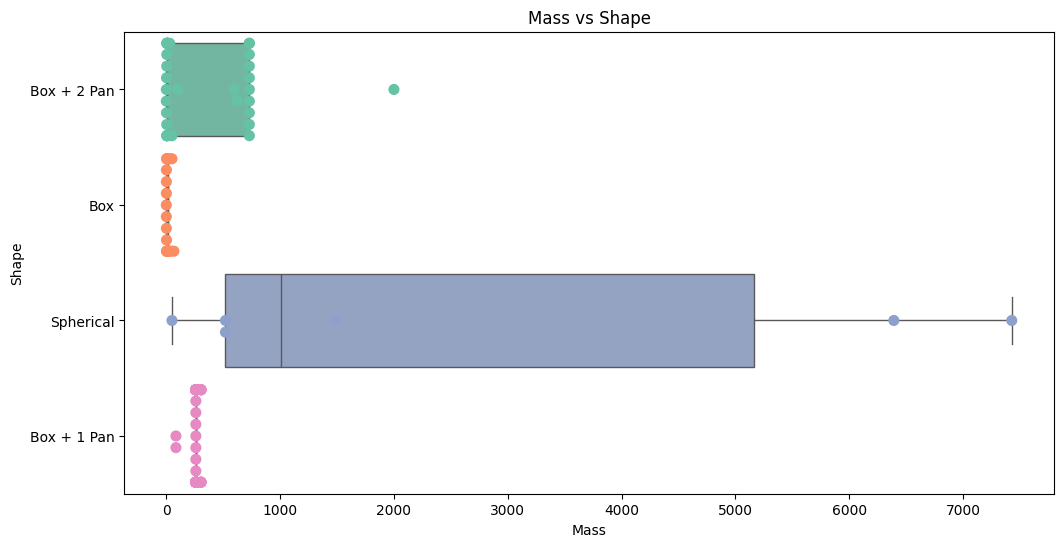

In [ ]:
# Combining a swarmplot and boxplot to visualize the distribution of mass for each shape
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='mass', y='simpshape', palette='Set2', whis = 1.5, showfliers=False)
sns.swarmplot(
    data=df,
    x="mass",
    y="simpshape",
    hue="simpshape",
    palette="Set2",
    size=8
)
plt.xlabel('Mass')
plt.ylabel('Shape')
plt.title('Mass vs Shape')
plt.show()

/var/folders/sf/t73_lfqj3n3b3q9nlt1bp4y40000gn/T/ipykernel_56205/2430244061.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning:

8.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning:

93.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



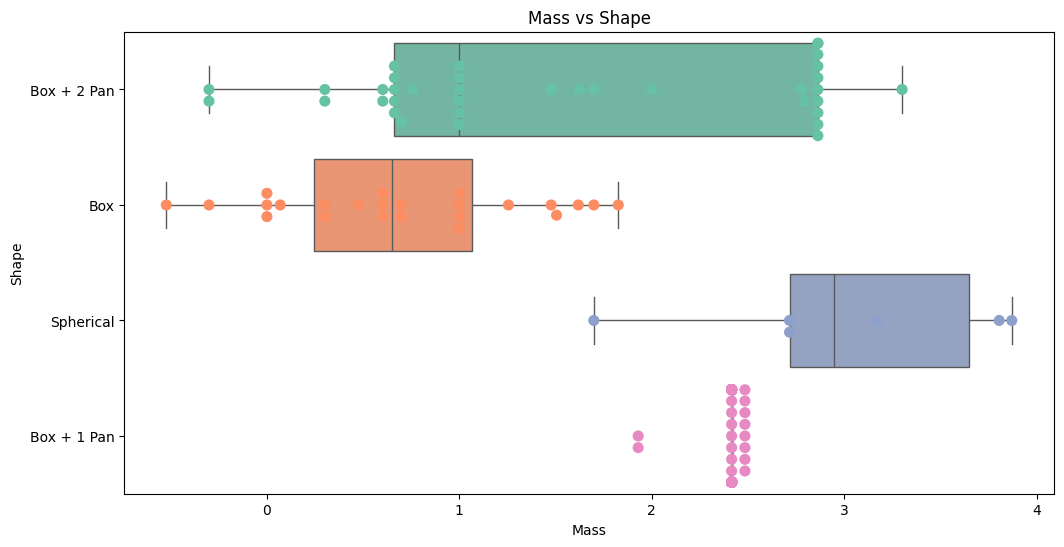

In [ ]:
# Reducing skewness by transforming mass values in logarithmic scale using log10

df['log_mass'] = np.log10(df['mass'])

plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='log_mass', y='simpshape', palette='Set2', whis = 1.5, showfliers=False)
sns.swarmplot(
    data=df,
    x="log_mass",
    y="simpshape",
    hue="simpshape",
    palette="Set2",
    size=8
)
plt.xlabel('Mass')
plt.ylabel('Shape')
plt.title('Mass vs Shape')
plt.show()

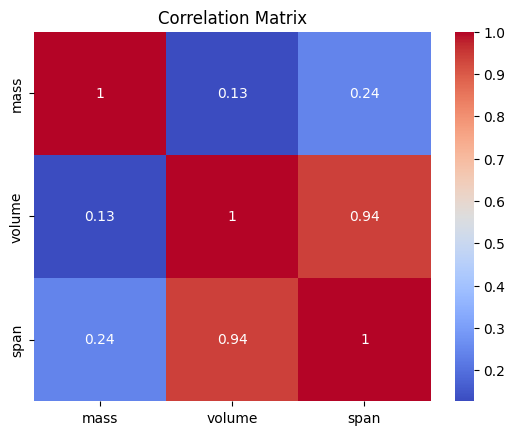

In [ ]:
# Creating a heatmap to visualize the correlation between mass, volume, and span
sns.heatmap(df[['mass','volume','span']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

As expected, volume and span dimensions have a high correlation value.

The same analysis can be done for volume and span of the objects.
Future implementations:
- PCA analysis
- Extract more interesting features by focusing on a specific question related to collisions